In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

print("Imports successful!")

Imports successful!


In [6]:
audio_path = "../data/Audio_Speech_Actors_01-24"

audio_files = glob.glob(os.path.join(audio_path, "Actor_*", "*.wav"))

print(f"Total audio files: {len(audio_files)}")

Total audio files: 1440


In [7]:
audio_files[:5]

['../data/Audio_Speech_Actors_01-24\\Actor_01\\03-01-01-01-01-01-01.wav',
 '../data/Audio_Speech_Actors_01-24\\Actor_01\\03-01-01-01-01-02-01.wav',
 '../data/Audio_Speech_Actors_01-24\\Actor_01\\03-01-01-01-02-01-01.wav',
 '../data/Audio_Speech_Actors_01-24\\Actor_01\\03-01-01-01-02-02-01.wav',
 '../data/Audio_Speech_Actors_01-24\\Actor_01\\03-01-02-01-01-01-01.wav']

In [8]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

print(emotion_map)

{'01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad', '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'}


In [9]:
data = []

for file_path in audio_files:
    file_name = os.path.basename(file_path)
    parts = file_name.replace(".wav", "").split("-")
    
    emotion_code = parts[2]
    emotion = emotion_map[emotion_code]
    
    data.append({
        "file_path": file_path,
        "emotion": emotion
    })

df = pd.DataFrame(data)

df.head()

,file_path,emotion
0,../data/Audio_Speech_Actors_01-24\Actor_01\03-...,neutral
1,../data/Audio_Speech_Actors_01-24\Actor_01\03-...,neutral
2,../data/Audio_Speech_Actors_01-24\Actor_01\03-...,neutral
3,../data/Audio_Speech_Actors_01-24\Actor_01\03-...,neutral
4,../data/Audio_Speech_Actors_01-24\Actor_01\03-...,calm


In [10]:
df["emotion"].value_counts()

emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

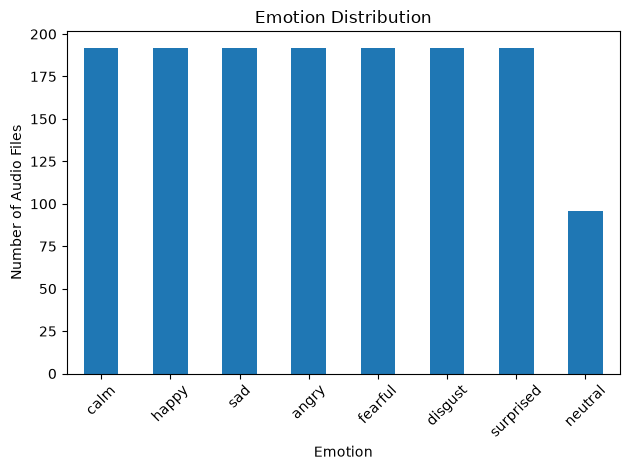

In [11]:
df["emotion"].value_counts().plot(kind="bar")

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
import IPython.display as ipd

sample_file = audio_files[0]

print(sample_file)

ipd.display(ipd.Audio(sample_file))

../data/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav


In [13]:
import wave

with wave.open(audio_files[0], "rb") as wav:
    sample_rate = wav.getframerate()
    frames = wav.getnframes()
    duration = frames / sample_rate

print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {duration:.2f} seconds")

Sample rate: 48000 Hz
Duration: 3.30 seconds


In [14]:
!pip install librosa

In [15]:
import librosa
import librosa.display

y, sr = librosa.load(audio_files[0], sr=None)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print("Audio shape:", y.shape)
print("Sample rate:", sr)
print("MFCC shape:", mfcc.shape)

Audio shape: (158558,)
Sample rate: 48000
MFCC shape: (13, 310)


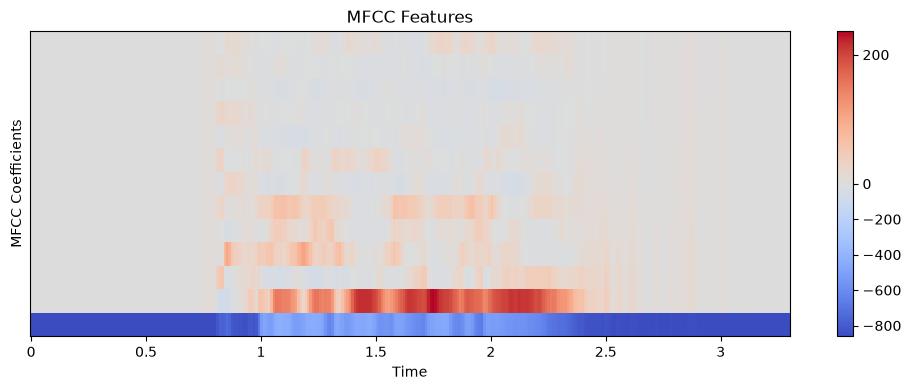

In [16]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title("MFCC Features")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

In [17]:
def extract_mfcc(file_path, n_mfcc=40, max_len=174):
    y, sr = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )

    # Make all samples the same size
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(
            mfcc,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc

In [18]:
import numpy as np

In [19]:
sample_mfcc = extract_mfcc(audio_files[0])

print("MFCC shape:", sample_mfcc.shape)

MFCC shape: (40, 174)


In [20]:
X = []
y = []

for i, row in df.iterrows():
    features = extract_mfcc(row["file_path"])
    
    X.append(features)
    y.append(row["emotion"])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 40, 174)
y shape: (1440,)


In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Encoded labels: [0 1 2 3 4 5 6 7]


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1152, 40, 174)
X_test: (288, 40, 174)
y_train: (1152,)
y_test: (288,)


In [23]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)

X_train_cnn: (1152, 40, 174, 1)
X_test_cnn: (288, 40, 174, 1)


In [24]:
!pip install tensorflow

In [25]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
TensorFlow: 2.21.0


In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X shape: (1440, 40, 174)
y shape: (1440,)
X_train shape: (1152, 40, 174)
X_test shape: (288, 40, 174)


In [27]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)

X_train_cnn: (1152, 40, 174, 1)
X_test_cnn: (288, 40, 174, 1)


In [28]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(40, 174, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(8, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772,488 (10.58 MB)

 Trainable params: 2,772,488 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.1542 - loss: 15.6243 - val_accuracy: 0.2121 - val_loss: 2.0109
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.2812 - loss: 1.9230 - val_accuracy: 0.3723 - val_loss: 1.7736
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4017 - loss: 1.6221 - val_accuracy: 0.3810 - val_loss: 1.5806
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.5201 - loss: 1.3535 - val_accuracy: 0.4459 - val_loss: 1.5343
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.6428 - loss: 1.0646 - val_accuracy: 0.4589 - val_loss: 1.5039
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.7079 - loss: 0.8364 - val_accuracy: 0.4545 - val_loss: 1.4862
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8317 - loss: 0.5167 - val_accuracy: 0.4632 - val_loss: 1.4999
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.8947 - loss: 0.3509 - val_accuracy: 0.5325 

In [30]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4549 - loss: 2.2853
Test Loss: 2.285311698913574
Test Accuracy: 0.4548611044883728


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
              precision    recall  f1-score   support

       angry       0.45      0.58      0.51        38
        calm       0.57      0.71      0.64        38
     disgust       0.49      0.45      0.47        38
     fearful       0.43      0.46      0.44        39
       happy       0.38      0.26      0.31        39
     neutral       0.34      0.58      0.43        19
         sad       0.17      0.08      0.11        38
   surprised       0.59      0.59      0.59        39

    accuracy                           0.45       288
   macro avg       0.43      0.46      0.44       288
weighted avg       0.43      0.45      0.44       288



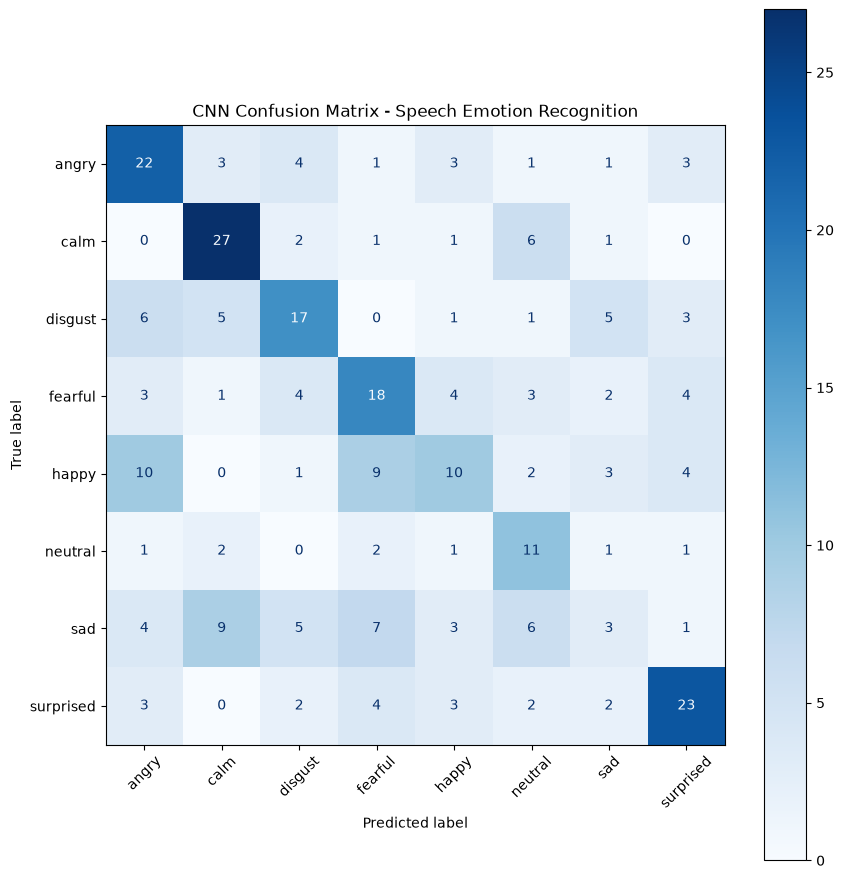

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("CNN Confusion Matrix - Speech Emotion Recognition")
plt.tight_layout()
plt.show()

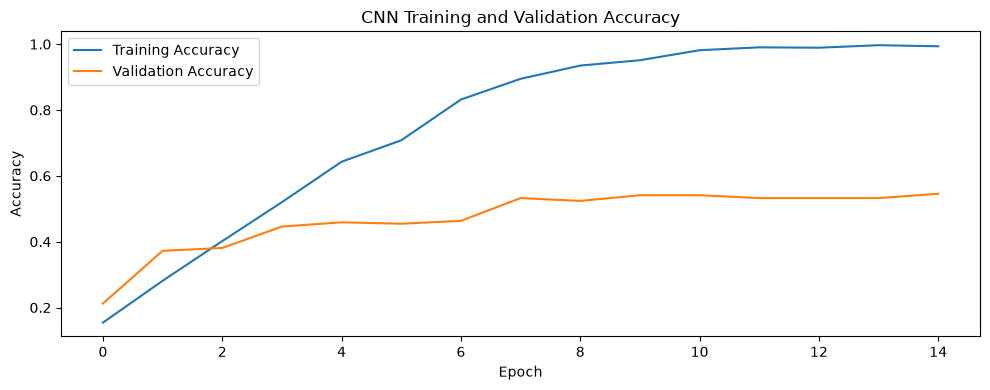

In [33]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
import os

os.makedirs("../models", exist_ok=True)

cnn_model.save("../models/speech_emotion_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


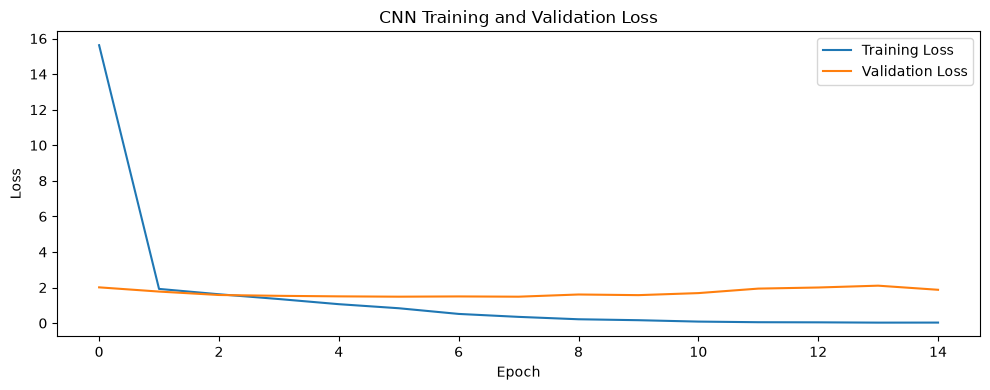

In [35]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
import os

model_path = "../models/speech_emotion_cnn.keras"

print("Model exists:", os.path.exists(model_path))
print("Model size (MB):", round(os.path.getsize(model_path) / (1024 * 1024), 2))

Model exists: True
Model size (MB): 31.77
